Homework 4, problem 4, part c

In [1]:
# loading libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
states = ["U", "I", "M", "F", "A"]

P = np.array([ # from problem 1
    [0,   1/2, 1/2, 0,   0],
    [1/4, 0,   0,   1/2, 1/4],
    [3/4, 0,   0,   0,   1/4],
    [0,   0,   0,   1,   0],
    [0,   0,   0,   0,   1]
])

N = 10000 # number of simulations

In [3]:
def simulate_chain(start):
    current = start
    time = 0

    while current not in ["F", "A"]:
        time += 1
        
        row = P[states.index(current)] # row of transition probabilities

        u = np.random.rand() # inverse transform
        cumulative = np.cumsum(row)

        next_index = np.where(u <= cumulative)[0][0]
        current = states[next_index]

    return time, current

In [4]:
results = {}

for start in ["U", "I", "M"]:

    times = []
    outcomes = []

    for _ in range(N):
        t, outcome = simulate_chain(start)

        times.append(t)
        outcomes.append(outcome)

    results[start] = {
        "times": np.array(times),
        "outcomes": np.array(outcomes)
    }

In [5]:
for start in ["U", "I", "M"]:

    times = results[start]["times"]
    outcomes = results[start]["outcomes"]

    h_hat = np.mean(outcomes == "F") # estimated probability of folding
    fold_times = times[outcomes == "F"] # times conditional on folding
    aggregate_times = times[outcomes == "A"] # times conditional on aggregation

    tau_F = np.mean(fold_times)
    tau_A = np.mean(aggregate_times)

    print(f"\nStarting from {start}:")
    print(f"h_hat = {h_hat:.4f}")
    print(f"g_hat = {tau_F:.4f}")
    print(f"tau_F = {tau_F:.4f}")
    print(f"tau_A = {tau_A:.4f}")


Starting from U:
h_hat = 0.4928
g_hat = 4.0511
tau_F = 4.0511
tau_A = 3.9602

Starting from I:
h_hat = 0.6190
g_hat = 1.7784
tau_F = 1.7784
tau_A = 2.3486

Starting from M:
h_hat = 0.3801
g_hat = 4.9963
tau_F = 4.9963
tau_A = 3.3110


In [6]:
times_I = results["I"]["times"]
outcomes_I = results["I"]["outcomes"]

fold_times = times_I[outcomes_I == "F"]
aggregate_times = times_I[outcomes_I == "A"]

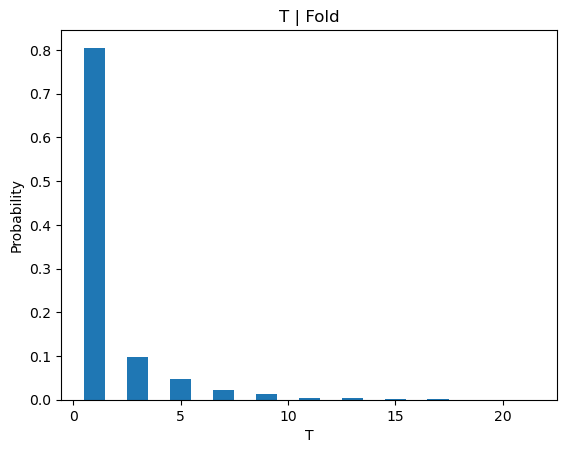

In [7]:
plt.hist(
    fold_times,
    bins = np.arange(0.5, max(fold_times) + 1.5, 1),
    density = True
)

plt.xlabel("T")
plt.ylabel("Probability")
plt.title("T | Fold")

plt.show()

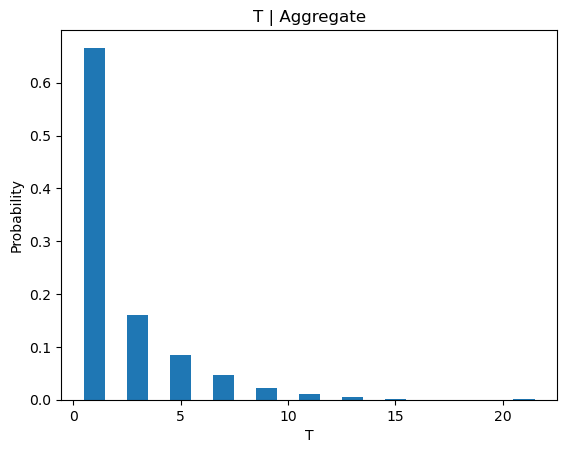

In [8]:
plt.hist(
    aggregate_times,
    bins=np.arange(0.5, max(aggregate_times) + 1.5, 1),
    density=True
)

plt.xlabel("T")
plt.ylabel("Probability")
plt.title("T | Aggregate")

plt.show()

In [9]:
Q = np.array([
    [0,   1/2, 1/2],
    [1/4, 0,   0],
    [3/4, 0,   0]
])

R = np.array([
    [0,   0],
    [1/2, 1/4],
    [0,   1/4]
])

In [10]:
h = np.linalg.solve(
    np.eye(3) - Q,
    R[:, 0]
)

print("h =", h)

h = [0.5   0.625 0.375]


In [11]:
h_I = h[1]
n_values = np.arange(1, 31)
pmf_fold = []

for n in n_values:

    Q_power = np.linalg.matrix_power(Q, n - 1)

    probability = (
        Q_power[1, :] @ R[:, 0]
    ) / h_I

    pmf_fold.append(probability)

pmf_fold = np.array(pmf_fold)

In [12]:
h_A = 1 - h_I
pmf_aggregate = []

for n in n_values:

    Q_power = np.linalg.matrix_power(Q, n - 1)

    probability = (
        Q_power[1, :] @ R[:, 1]
    ) / h_A

    pmf_aggregate.append(probability)

pmf_aggregate = np.array(pmf_aggregate)

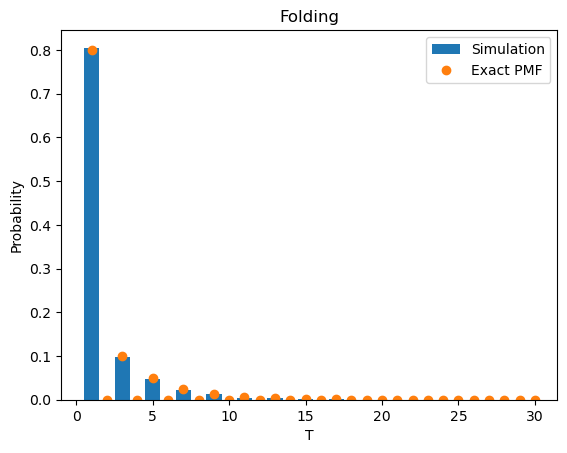

In [13]:
plt.hist(
    fold_times,
    bins = np.arange(0.5, max(fold_times) + 1.5, 1),
    density = True,
    label = "Simulation"
)

plt.plot(
    n_values,
    pmf_fold,
    "o",
    label="Exact PMF"
)

plt.xlabel("T")
plt.ylabel("Probability")
plt.title("Folding")
plt.legend()

plt.show()

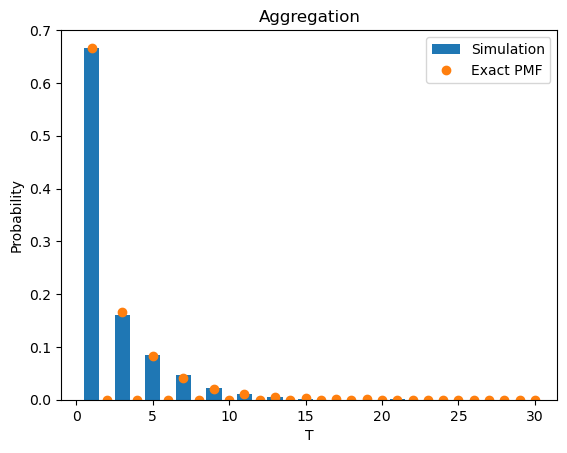

In [14]:
plt.hist(
    aggregate_times,
    bins = np.arange(0.5, max(aggregate_times) + 1.5, 1),
    density = True,
    label = "Simulation"
)

plt.plot(
    n_values,
    pmf_aggregate,
    "o",
    label = "Exact PMF"
)

plt.xlabel("T")
plt.ylabel("Probability")
plt.title("Aggregation")
plt.legend()

plt.show()